# Binomialverteilung und Normalverteilung

Dieses Notebook veranschaulicht den **Zentralen Grenzwertsatz (ZGS)** am Beispiel der Binomialverteilung:

Für große $n$ gilt näherungsweise:
$$B(n;\, p) \approx \mathcal{N}\!\left(\mu,\, \sigma^2\right) \quad \text{mit} \quad \mu = n \cdot p, \quad \sigma^2 = n \cdot p \cdot (1-p)$$

Als Faustregel gilt die **Laplace-Bedingung**: $n \cdot p \cdot (1-p) \geq 9$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Module geladen.')


Module geladen.


## 1. Einzelplot: Binomialverteilung vs. Normalapproximation

Passe `n` und `p` nach Belieben an.

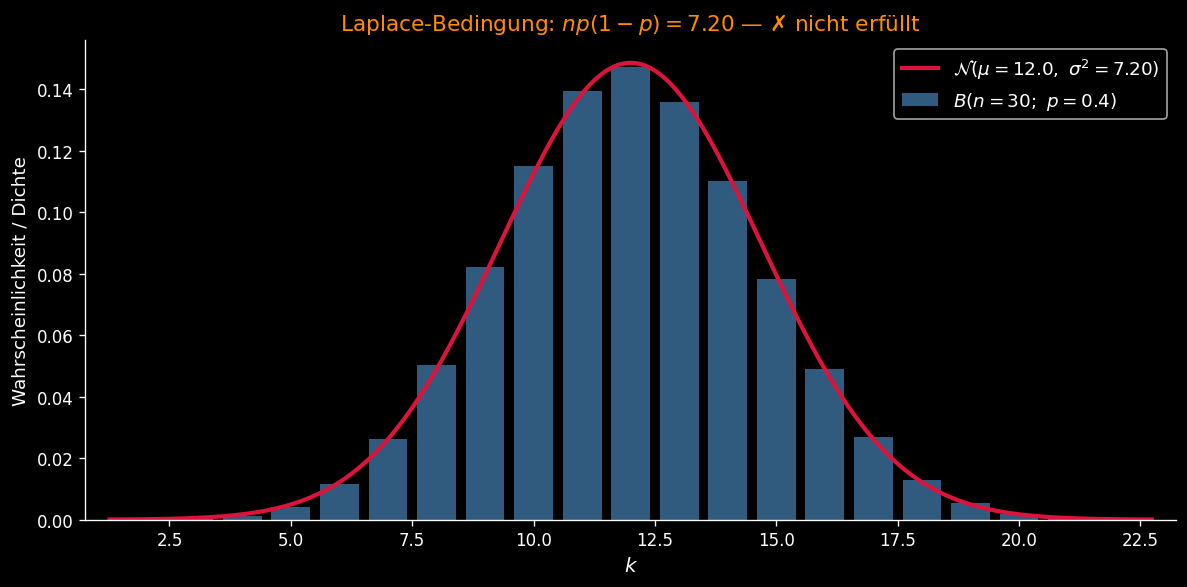

In [10]:
# --- Parameter anpassen ---
n = 30
p = 0.4
# --------------------------

mu      = n * p
sigma   = np.sqrt(n * p * (1 - p))
laplace = n * p * (1 - p)

k = np.arange(0, n + 1)
x = np.linspace(max(0, mu - 4*sigma), min(n, mu + 4*sigma), 400)

lbl_binom  = fr'$B(n={n};\ p={p})$'
lbl_normal = fr'$\mathcal{{N}}(\mu={mu:.1f},\ \sigma^2={laplace:.2f})$'

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(k, binom.pmf(k, n, p), color='steelblue', alpha=0.7, label=lbl_binom, zorder=2)
ax.plot(x, norm.pdf(x, mu, sigma), color='crimson', lw=2.5, label=lbl_normal)

status = '✓ erfüllt' if laplace >= 9 else '✗ nicht erfüllt'
farbe  = 'green'       if laplace >= 9 else 'darkorange'
ax.set_title(f'Laplace-Bedingung: $np(1-p) = {laplace:.2f}$ — {status}',
             color=farbe, fontsize=13)
ax.set_xlabel('$k$', fontsize=12)
ax.set_ylabel('Wahrscheinlichkeit / Dichte', fontsize=11)
ax.set_xlim(mu - 4*sigma - 0.5, mu + 4*sigma + 0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 2. Konvergenz bei steigendem $n$ (festes $p = 0{,}3$)

Mit wachsendem $n$ wird die Binomialverteilung symmetrischer und nähert sich der Glockenkurve an.

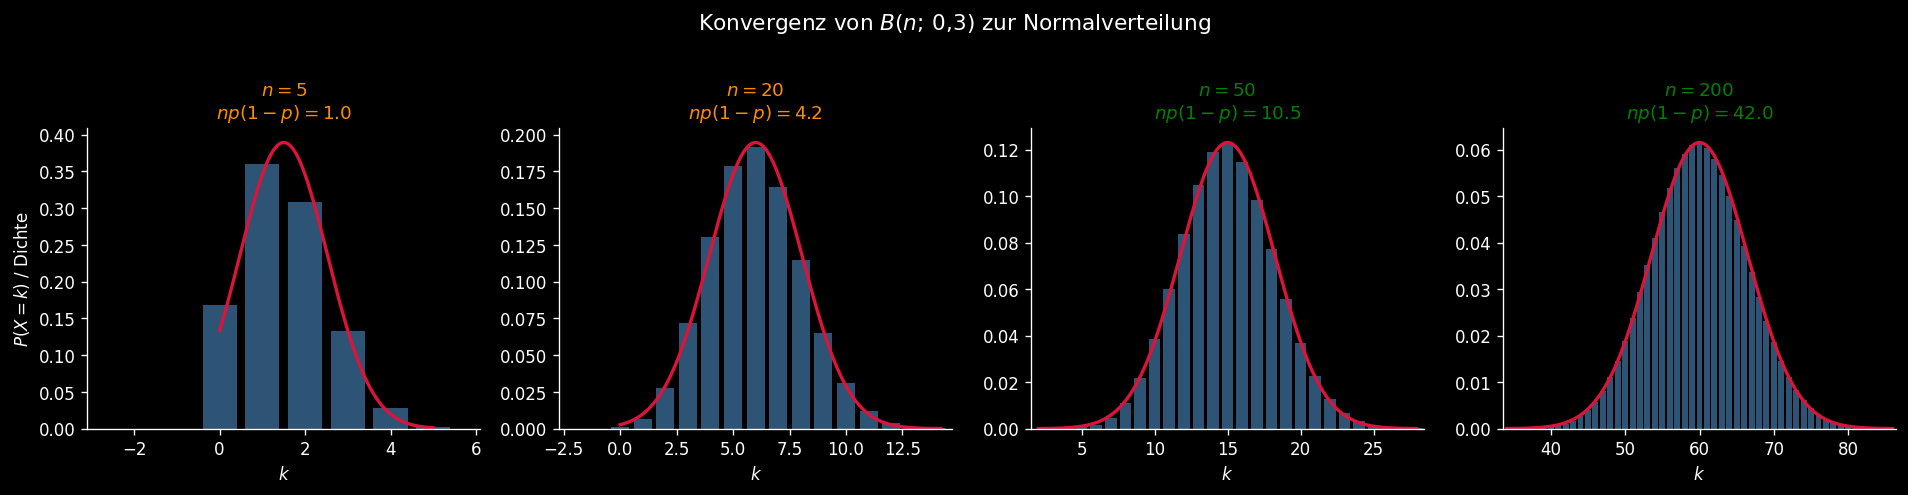

In [11]:
p_fix   = 0.3
n_werte = [5, 20, 50, 200]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n in zip(axes, n_werte):
    mu      = n * p_fix
    sigma   = np.sqrt(n * p_fix * (1 - p_fix))
    laplace = n * p_fix * (1 - p_fix)

    k = np.arange(0, n + 1)
    x = np.linspace(max(0, mu - 4*sigma), min(n, mu + 4*sigma), 400)

    ax.bar(k, binom.pmf(k, n, p_fix), color='steelblue', alpha=0.65, zorder=2)
    ax.plot(x, norm.pdf(x, mu, sigma), color='crimson', lw=2)

    farbe = 'green' if laplace >= 9 else 'darkorange'
    ax.set_title(f'$n = {n}$\n$np(1-p) = {laplace:.1f}$', color=farbe, fontsize=11)
    ax.set_xlabel('$k$')
    ax.set_xlim(mu - 4*sigma - 0.5, mu + 4*sigma + 0.5)

axes[0].set_ylabel('$P(X = k)$ / Dichte')
fig.suptitle(r'Konvergenz von $B(n;\, 0{,}3)$ zur Normalverteilung', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. Einfluss von $p$: Symmetrie und Schiefe

Bei $p = 0{,}5$ ist die Binomialverteilung symmetrisch; für $p \neq 0{,}5$ ist sie schief.

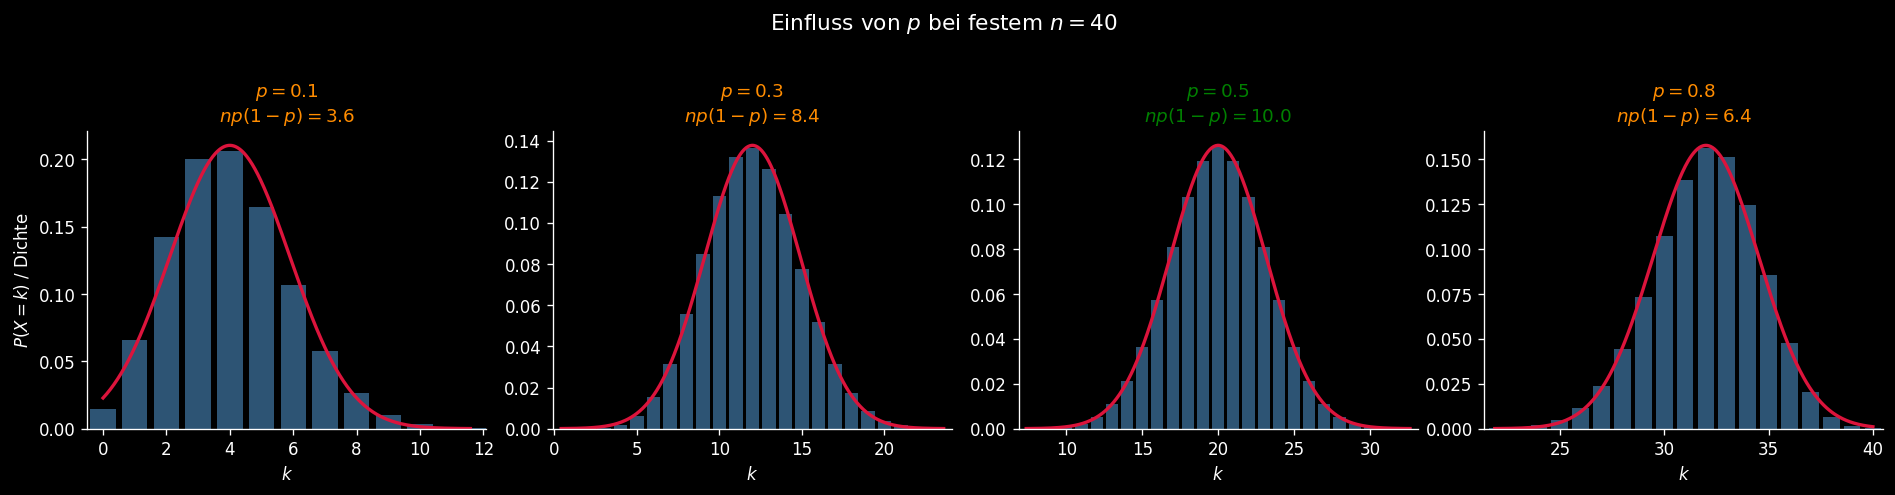

In [12]:
n_fix   = 40
p_werte = [0.1, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, p in zip(axes, p_werte):
    mu      = n_fix * p
    sigma   = np.sqrt(n_fix * p * (1 - p))
    laplace = n_fix * p * (1 - p)

    k = np.arange(0, n_fix + 1)
    x = np.linspace(max(0, mu - 4*sigma), min(n_fix, mu + 4*sigma), 400)

    ax.bar(k, binom.pmf(k, n_fix, p), color='steelblue', alpha=0.65, zorder=2)
    ax.plot(x, norm.pdf(x, mu, sigma), color='crimson', lw=2)

    farbe = 'green' if laplace >= 9 else 'darkorange'
    ax.set_title(f'$p = {p}$\n$np(1-p) = {laplace:.1f}$', color=farbe, fontsize=11)
    ax.set_xlabel('$k$')
    ax.set_xlim(max(-0.5, mu - 4*sigma - 0.5), min(n_fix + 0.5, mu + 4*sigma + 0.5))

axes[0].set_ylabel('$P(X = k)$ / Dichte')
fig.suptitle(f'Einfluss von $p$ bei festem $n = {n_fix}$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Stetigkeitskorrektur

Da die Binomialverteilung **diskret** und die Normalverteilung **stetig** ist, verbessert die **Stetigkeitskorrektur** die Approximation:

$$P(X \leq k) \approx \Phi\!\left(\frac{k + 0{,}5 - \mu}{\sigma}\right)$$

Das $+0{,}5$ berücksichtigt, dass der Balken bei $k$ die Breite 1 hat und bis $k + 0{,}5$ reicht.

P(X <= 14) fuer B(n=30, p=0.4):
  Exakt (Binomial):                   0.824631
  Normal ohne Stetigkeitskorrektur:   0.771972  (Fehler: 0.052659)
  Normal mit Stetigkeitskorrektur:    0.824253  (Fehler: 0.000378)


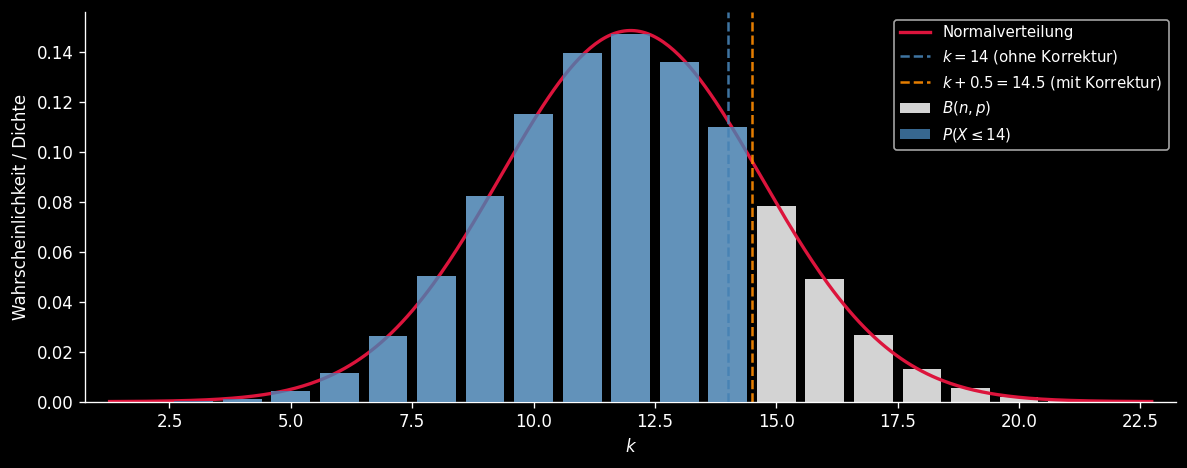

In [13]:
# --- Parameter anpassen ---
n     = 30
p     = 0.4
k_max = 14
# --------------------------

mu    = n * p
sigma = np.sqrt(n * p * (1 - p))

exakt     = binom.cdf(k_max, n, p)
ohne_korr = norm.cdf((k_max       - mu) / sigma)
mit_korr  = norm.cdf((k_max + 0.5 - mu) / sigma)

print(f'P(X <= {k_max}) fuer B(n={n}, p={p}):')
print(f'  Exakt (Binomial):                   {exakt:.6f}')
print(f'  Normal ohne Stetigkeitskorrektur:   {ohne_korr:.6f}  (Fehler: {abs(exakt - ohne_korr):.6f})')
print(f'  Normal mit Stetigkeitskorrektur:    {mit_korr:.6f}  (Fehler: {abs(exakt - mit_korr):.6f})')

k = np.arange(0, n + 1)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(k, binom.pmf(k, n, p), color='lightgray', zorder=2, label='$B(n,p)$')
ax.bar(k[k <= k_max], binom.pmf(k, n, p)[k <= k_max],
       color='steelblue', alpha=0.8, zorder=3, label=f'$P(X \\leq {k_max})$')
ax.plot(x, norm.pdf(x, mu, sigma), 'crimson', lw=2, label='Normalverteilung')
ax.axvline(k_max,       color='steelblue',  ls='--', alpha=0.9,
           label=f'$k = {k_max}$ (ohne Korrektur)')
ax.axvline(k_max + 0.5, color='darkorange', ls='--', alpha=0.9,
           label=f'$k + 0.5 = {k_max + 0.5}$ (mit Korrektur)')
ax.set_xlabel('$k$')
ax.set_ylabel('Wahrscheinlichkeit / Dichte')
ax.set_xlim(mu - 4*sigma - 0.5, mu + 4*sigma + 0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 5. Zusammenfassung

| Eigenschaft | Binomialverteilung $B(n; p)$ | Normalapproximation $\mathcal{N}(\mu, \sigma^2)$ |
|---|---|---|
| Erwartungswert | $\mu = n \cdot p$ | $\mu = n \cdot p$ |
| Varianz | $\sigma^2 = n \cdot p \cdot (1-p)$ | $\sigma^2 = n \cdot p \cdot (1-p)$ |
| Typ | diskret | stetig |
| Gültigkeitsbereich | immer exakt | Faustregel: $n \cdot p \cdot (1-p) \geq 9$ |
| Stetigkeitskorrektur | — | $P(X \leq k) \approx \Phi\!\left(\tfrac{k+0{,}5-\mu}{\sigma}\right)$ |

**Fazit:** Die Normalverteilung approximiert die Binomialverteilung für große $n$ gut, sofern die Laplace-Bedingung erfüllt ist. Die Stetigkeitskorrektur verbessert die Genauigkeit spürbar.